# Exact Empirical Second-Order Stochastic Dominance

This notebook investigates whether a long-only ETF portfolio can satisfy exact empirical second-order stochastic dominance relative to SPY.

At each formation date, the preceding three years of daily returns are treated as equally likely historical scenarios. Portfolio weights are selected using only information available before the formation date.

A portfolio return \(R_p\) second-order stochastically dominates the benchmark return \(R_b\) if

$$
\mathbb{E}[u(R_p)] \geq \mathbb{E}[u(R_b)]
$$

for every increasing and concave utility function \(u\). Economically, this means that every risk-averse investor who prefers more return would weakly prefer the optimized portfolio to the benchmark.

For equally weighted empirical scenarios, the SSD requirement can be represented using cumulative ordered returns:

$$
\sum_{i=1}^{k} R_{p,(i)}
\geq
\sum_{i=1}^{k} R_{b,(i)},
\qquad
k=1,\ldots,T,
$$

where \(R_{(i)}\) denotes the \(i\)-th smallest return. These constraints require the optimized portfolio to perform at least as well as the benchmark across every cumulative portion of the lower return distribution.

The single-period optimization problem is

$$
\begin{aligned}
\max_w \quad
& \hat{\mu}^{\top}w \\[2mm]
\text{subject to}\quad
& \sum_{i=1}^{k} R_{p,(i)}
\geq
\sum_{i=1}^{k} R_{\mathrm{SPY},(i)},
\qquad k=1,\ldots,T,\\
& \mathbf{1}^{\top}w=1,\\
& w\geq0.
\end{aligned}
$$

SPY is used as the benchmark but is excluded from the investable universe. Otherwise, allocating 100% of the portfolio to SPY would provide a trivial feasible solution.

The analysis begins with the first formation date to determine whether the exact empirical SSD constraints admit a nontrivial feasible portfolio. If the exact model is infeasible or excessively restrictive, the result will motivate a separate relaxed-dominance formulation in the following notebook.


### Cutting-Plane Implementation

Imposing all empirical stochastic-dominance constraints simultaneously may be computationally expensive when the estimation window contains many return scenarios. Instead of including every constraint in the initial optimization problem, the model can be solved using a cutting-plane procedure.

The algorithm begins with a restricted master problem containing only a small subset of the dominance constraints. After obtaining a candidate portfolio, a separation problem is solved to identify the most violated stochastic-dominance condition. If a violated condition exists, the corresponding constraint is added to the master problem and the portfolio is reoptimized. This process continues until no violated dominance constraint can be found.

Because the empirical return distribution contains finitely many scenarios and therefore finitely many relevant benchmark thresholds, the procedure terminates after finitely many iterations. At convergence, the resulting portfolio satisfies the complete set of empirical stochastic-dominance constraints, even though most constraints may never need to be explicitly added to the optimization model.


In [66]:
from pathlib import Path

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TRADING_DAYS = 252
ESTIMATION_YEARS = 3

BENCHMARK_NAME = "SPY"
SOLVER = "CLARABEL"

sns.set_theme(style="whitegrid")

In [67]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "etf_adjusted_close.csv"
)

prices = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=["Date"],
)

prices = prices.sort_index()

returns = (
    prices
    .pct_change(fill_method=None)
    .dropna()
)

print("Project root:", PROJECT_ROOT)
print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
print(
    "Return period:",
    returns.index.min(),
    "to",
    returns.index.max(),
)

returns.head()

Project root: /Users/yyi/Projects/Portfolio optimization
Prices shape: (3268, 12)
Returns shape: (3267, 12)
Return period: 2007-04-12 00:00:00 to 2020-04-01 00:00:00


,SPY,QQQ,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-12,0.004444,0.007917,0.006725,0.006677,0.016719,0.000970,0.000228,0.001505,0.000671,-0.001342,0.005903,-0.006805
2007-04-13,0.004562,0.002020,0.006432,0.003316,0.004909,-0.001697,-0.003089,-0.001690,-0.001820,0.012688,0.005477,0.011292
2007-04-16,0.009496,0.009182,0.013767,0.010552,0.011886,0.001093,0.005510,0.000847,-0.000384,0.008255,-0.007782,0.001255
2007-04-17,0.002658,0.002219,-0.003031,0.000126,-0.005391,0.004246,0.005594,0.005452,-0.000480,-0.005848,-0.010196,0.013033
2007-04-18,0.001224,-0.003322,-0.005837,-0.000377,-0.007442,0.002295,0.004995,0.000280,0.000288,0.005588,0.000396,-0.006185


In [68]:
assert BENCHMARK_NAME in returns.columns

asset_names = returns.columns.drop(BENCHMARK_NAME)

investable_returns = returns[asset_names]
benchmark_returns = returns[BENCHMARK_NAME]

print("Benchmark:", BENCHMARK_NAME)
print("Number of investable assets:", len(asset_names))
print("Investable assets:", asset_names.tolist())

Benchmark: SPY
Number of investable assets: 11
Investable assets: ['QQQ', 'IWM', 'EFA', 'EEM', 'IEF', 'TLT', 'LQD', 'HYG', 'GLD', 'DBC', 'VNQ']


In [69]:
backtest_start = returns.index[
    returns.index
    >= returns.index.min()
    + pd.DateOffset(years=ESTIMATION_YEARS)
][0]

backtest_end = returns.index.max()

print(
    "Full return period:",
    returns.index.min(),
    "to",
    returns.index.max(),
)

print(
    "Backtest period:",
    backtest_start,
    "to",
    backtest_end,
)

Full return period: 2007-04-12 00:00:00 to 2020-04-01 00:00:00
Backtest period: 2010-04-12 00:00:00 to 2020-04-01 00:00:00


In [70]:
requested_formation_date = pd.Timestamp(
    "2017-01-03"
)

# Make sure the requested date is an actual
# trading date in the return data.
formation_date = returns.index[
    returns.index >= requested_formation_date
][0]

estimation_start = (
    formation_date
    - pd.DateOffset(years=ESTIMATION_YEARS)
)

estimation_returns = returns.loc[
    (returns.index >= estimation_start)
    & (returns.index < formation_date)
].copy()

print("Formation date:", formation_date)

print(
    "Estimation period:",
    estimation_returns.index.min(),
    "to",
    estimation_returns.index.max(),
)

print(
    "Number of historical scenarios:",
    len(estimation_returns),
)

Formation date: 2017-01-03 00:00:00
Estimation period: 2014-01-03 00:00:00 to 2016-12-30 00:00:00
Number of historical scenarios: 755


In [71]:
portfolio_scenario_returns = (
    estimation_returns[asset_names]
)

benchmark_scenario_returns = (
    estimation_returns[BENCHMARK_NAME]
)

print(
    "Portfolio scenario matrix:",
    portfolio_scenario_returns.shape,
)

print(
    "Benchmark scenario vector:",
    benchmark_scenario_returns.shape,
)

Portfolio scenario matrix: (755, 11)
Benchmark scenario vector: (755,)


In [72]:
scenario_return_matrix = (
    portfolio_scenario_returns
    .to_numpy(dtype=float)
)

benchmark_return_vector = (
    benchmark_scenario_returns
    .to_numpy(dtype=float)
)

number_of_scenarios = scenario_return_matrix.shape[0]
number_of_assets = scenario_return_matrix.shape[1]

print("Number of scenarios:", number_of_scenarios)
print("Number of assets:", number_of_assets)
print("Scenario matrix shape:", scenario_return_matrix.shape)
print("Benchmark vector shape:", benchmark_return_vector.shape)

Number of scenarios: 755
Number of assets: 11
Scenario matrix shape: (755, 11)
Benchmark vector shape: (755,)


In [73]:
assert number_of_scenarios > 0
assert number_of_assets > 0

assert scenario_return_matrix.shape == (
    number_of_scenarios,
    number_of_assets,
)

assert benchmark_return_vector.shape == (
    number_of_scenarios,
)

assert np.isfinite(scenario_return_matrix).all()
assert np.isfinite(benchmark_return_vector).all()

assert not portfolio_scenario_returns.isna().any().any()
assert not benchmark_scenario_returns.isna().any()

print("Data validation passed.")

Data validation passed.


In [74]:
sorted_benchmark_returns = np.sort(
    benchmark_return_vector
)

benchmark_cumulative_returns = np.cumsum(
    sorted_benchmark_returns
)

dominance_indices = np.arange(
    1,
    number_of_scenarios + 1,
)

benchmark_ssd_table = pd.DataFrame(
    {
        "Ordered Benchmark Return":
            sorted_benchmark_returns,
        "Cumulative Benchmark Return":
            benchmark_cumulative_returns,
    },
    index=dominance_indices,
)

benchmark_ssd_table.index.name = "k"

benchmark_ssd_table.head(10)

,Ordered Benchmark Return,Cumulative Benchmark Return
k,,
1,-0.042107,-0.042107
2,-0.035909,-0.078016
3,-0.030103,-0.108119
4,-0.029848,-0.137967
5,-0.025097,-0.163064
6,-0.024941,-0.188005
7,-0.023992,-0.211996
8,-0.023935,-0.235931
9,-0.022505,-0.258436


In [75]:
inspection_indices = sorted(
    set(
        [
            1,
            5,
            10,
            int(0.05 * number_of_scenarios),
            int(0.10 * number_of_scenarios),
            int(0.25 * number_of_scenarios),
            int(0.50 * number_of_scenarios),
            number_of_scenarios,
        ]
    )
)

inspection_indices = [
    k for k in inspection_indices
    if 1 <= k <= number_of_scenarios
]

benchmark_ssd_table.loc[inspection_indices]

,Ordered Benchmark Return,Cumulative Benchmark Return
k,,
1,-0.042107,-0.042107
5,-0.025097,-0.163064
10,-0.021466,-0.279902
37,-0.014003,-0.746035
75,-0.009477,-1.190535
188,-0.003536,-1.886874
377,0.000492,-2.132160
755,0.038394,0.288229


In [76]:
# Start with the mean-dominance condition at k = T.
active_cut_indices = [number_of_scenarios]

cutting_plane_history = []

MAX_CUTTING_PLANE_ITERATIONS = (
    number_of_scenarios
)

DOMINANCE_TOLERANCE = 1e-8

print("Initial active cut indices:", active_cut_indices)
print("Dominance tolerance:", DOMINANCE_TOLERANCE)

Initial active cut indices: [755]
Dominance tolerance: 1e-08


In [77]:
def solve_restricted_master_problem(
    active_cut_indices,
):
    """
    Maximize estimated mean return subject to:
    1. fully invested;
    2. long-only;
    3. the currently active empirical SSD constraints.
    """

    portfolio_weights = cp.Variable(
        number_of_assets,
        name="portfolio_weights",
    )

    portfolio_scenario_expression = (
        scenario_return_matrix
        @ portfolio_weights
    )

    estimated_mean_return = cp.sum(
        portfolio_scenario_expression
    ) / number_of_scenarios

    constraints = [
        cp.sum(portfolio_weights) == 1,
        portfolio_weights >= 0,
    ]

    for k in active_cut_indices:

        benchmark_cumulative_return = (
            benchmark_cumulative_returns[k - 1]
        )

        if k == number_of_scenarios:
            portfolio_cumulative_return = cp.sum(
                portfolio_scenario_expression
            )
        else:
            portfolio_cumulative_return = cp.sum_smallest(
                portfolio_scenario_expression,
                k,
            )

        constraints.append(
            portfolio_cumulative_return
            >= benchmark_cumulative_return
        )

    objective = cp.Maximize(
        estimated_mean_return
    )

    problem = cp.Problem(
        objective,
        constraints,
    )

    problem.solve(solver=SOLVER)

    if problem.status not in [
        "optimal",
        "optimal_inaccurate",
    ]:
        return {
            "status": problem.status,
            "weights": None,
            "objective_value": None,
        }

    optimized_weights = pd.Series(
        portfolio_weights.value,
        index=asset_names,
        name="Weight",
    )

    # Remove negligible numerical errors.
    optimized_weights = optimized_weights.clip(
        lower=0
    )

    optimized_weights /= optimized_weights.sum()

    return {
        "status": problem.status,
        "weights": optimized_weights,
        "objective_value": problem.value,
    }

In [78]:
def find_most_violated_ssd_constraint(
    optimized_weights,
):
    """
    Evaluate every empirical SSD constraint and return
    the most violated one.
    """

    portfolio_return_vector = (
        scenario_return_matrix
        @ optimized_weights.to_numpy()
    )

    sorted_portfolio_returns = np.sort(
        portfolio_return_vector
    )

    portfolio_cumulative_returns = np.cumsum(
        sorted_portfolio_returns
    )

    dominance_slacks = (
        portfolio_cumulative_returns
        - benchmark_cumulative_returns
    )

    # A negative slack means that the SSD constraint
    # is violated.
    most_violated_position = np.argmin(
        dominance_slacks
    )

    most_violated_k = (
        most_violated_position + 1
    )

    minimum_slack = dominance_slacks[
        most_violated_position
    ]

    maximum_violation = max(
        0.0,
        -minimum_slack,
    )

    return {
        "most_violated_k": most_violated_k,
        "minimum_slack": minimum_slack,
        "maximum_violation": maximum_violation,
        "dominance_slacks": dominance_slacks,
        "portfolio_returns": portfolio_return_vector,
        "portfolio_cumulative_returns":
            portfolio_cumulative_returns,
    }

In [79]:
initial_result = (
    solve_restricted_master_problem(
        active_cut_indices
    )
)

print(
    "Initial problem status:",
    initial_result["status"],
)

print(
    "Initial estimated daily return:",
    initial_result["objective_value"],
)

if initial_result["weights"] is not None:
    display(
        initial_result["weights"]
        .sort_values(ascending=False)
        .to_frame()
        .style.format("{:.2%}")
    )

Initial problem status: optimal
Initial estimated daily return: 0.000538521786928437


,Weight
VNQ,100.00%
QQQ,0.00%
TLT,0.00%
IWM,0.00%
LQD,0.00%
IEF,0.00%
HYG,0.00%
EFA,0.00%
EEM,0.00%
GLD,0.00%


In [80]:
if initial_result["weights"] is not None:

    initial_separation = (
        find_most_violated_ssd_constraint(
            initial_result["weights"]
        )
    )

    print(
        "Most violated k:",
        initial_separation[
            "most_violated_k"
        ],
    )

    print(
        "Minimum dominance slack:",
        initial_separation[
            "minimum_slack"
        ],
    )

    print(
        "Maximum violation:",
        initial_separation[
            "maximum_violation"
        ],
    )

Most violated k: 310
Minimum dominance slack: -0.39516358609086355
Maximum violation: 0.39516358609086355


In [81]:
active_cut_indices = [
    number_of_scenarios
]

cutting_plane_history = []

final_result = None
final_separation = None

for iteration in range(
    1,
    MAX_CUTTING_PLANE_ITERATIONS + 1,
):

    master_result = (
        solve_restricted_master_problem(
            active_cut_indices
        )
    )

    if master_result["weights"] is None:
        print(
            f"Iteration {iteration}: "
            f"master problem is "
            f"{master_result['status']}."
        )

        final_result = master_result
        break

    separation_result = (
        find_most_violated_ssd_constraint(
            master_result["weights"]
        )
    )

    most_violated_k = separation_result[
        "most_violated_k"
    ]

    maximum_violation = separation_result[
        "maximum_violation"
    ]

    cutting_plane_history.append(
        {
            "Iteration": iteration,
            "Number of Active Cuts":
                len(active_cut_indices),
            "Estimated Daily Return":
                master_result[
                    "objective_value"
                ],
            "Most Violated k":
                most_violated_k,
            "Maximum Violation":
                maximum_violation,
        }
    )

    print(
        f"Iteration {iteration:>3}: "
        f"cuts = {len(active_cut_indices):>3}, "
        f"most violated k = "
        f"{most_violated_k:>4}, "
        f"maximum violation = "
        f"{maximum_violation:.10f}"
    )

    final_result = master_result
    final_separation = separation_result

    if (
        maximum_violation
        <= DOMINANCE_TOLERANCE
    ):
        print(
            "\nNo materially violated "
            "SSD constraint remains."
        )
        break

    if most_violated_k in active_cut_indices:
        print(
            "\nThe most violated constraint "
            "is already active. The remaining "
            "violation is likely caused by "
            "solver tolerance."
        )
        break

    active_cut_indices.append(
        most_violated_k
    )

    active_cut_indices.sort()

Iteration   1: cuts =   1, most violated k =  310, maximum violation = 0.3951635861
Iteration   2: cuts =   2, most violated k =  282, maximum violation = 0.0047546898
Iteration   3: cuts =   3, most violated k =  278, maximum violation = 0.0003150218
Iteration   4: cuts =   4, most violated k =  280, maximum violation = 0.0000420875
Iteration   5: cuts =   5, most violated k =  280, maximum violation = 0.0000000000

No materially violated SSD constraint remains.


In [82]:
cutting_plane_history_df = pd.DataFrame(
    cutting_plane_history
).set_index("Iteration")

cutting_plane_history_df

,Number of Active Cuts,Estimated Daily Return,Most Violated k,Maximum Violation
Iteration,,,,
1,1,0.000539,310,0.395164
2,2,0.000518,282,0.004755
3,3,0.000518,278,0.000315
4,4,0.000518,280,0.000042
5,5,0.000518,280,0.000000


In [83]:
final_weights = final_result["weights"]

final_portfolio_returns = (
    scenario_return_matrix
    @ final_weights.to_numpy()
)

final_sorted_returns = np.sort(
    final_portfolio_returns
)

final_cumulative_returns = np.cumsum(
    final_sorted_returns
)

final_dominance_slacks = (
    final_cumulative_returns
    - benchmark_cumulative_returns
)

tightest_position = np.argmin(
    final_dominance_slacks
)

tightest_k = tightest_position + 1

minimum_slack = final_dominance_slacks[
    tightest_position
]

maximum_violation = max(
    0.0,
    -minimum_slack,
)

print("Final problem status:", final_result["status"])

print(
    "Number of active cuts:",
    len(active_cut_indices),
)

print("Tightest k:", tightest_k)

print(
    "Minimum slack:",
    f"{minimum_slack:.16e}",
)

print(
    "Maximum violation:",
    f"{maximum_violation:.16e}",
)

print(
    "Portfolio worst daily return:",
    final_portfolio_returns.min(),
)

print(
    "SPY worst daily return:",
    benchmark_return_vector.min(),
)

print(
    "Portfolio estimated daily mean:",
    final_portfolio_returns.mean(),
)

print(
    "SPY estimated daily mean:",
    benchmark_return_vector.mean(),
)

print(
    "All SSD constraints satisfied:",
    (
        final_dominance_slacks
        >= -DOMINANCE_TOLERANCE
    ).all(),
)

Final problem status: optimal
Number of active cuts: 5
Tightest k: 280
Minimum slack: 1.2092053403023328e-07
Maximum violation: 0.0000000000000000e+00
Portfolio worst daily return: -0.04187726664308409
SPY worst daily return: -0.04210679353641511
Portfolio estimated daily mean: 0.0005179591428639964
SPY estimated daily mean: 0.0003817609077623569
All SSD constraints satisfied: True


In [84]:
comparison_statistics = pd.DataFrame(
    {
        "GLD Portfolio":
            initial_portfolio_returns,
        "SPY Benchmark":
            benchmark_return_vector,
    }
).describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

comparison_statistics

,GLD Portfolio,SPY Benchmark
count,755.000000,755.000000
mean,0.000539,0.000382
std,0.009610,0.008403
min,-0.046815,-0.042107
1%,-0.027155,-0.023163
5%,-0.016892,-0.013966
10%,-0.011246,-0.009393
25%,-0.004545,-0.003479
50%,0.000952,0.000495
75%,0.006383,0.004921


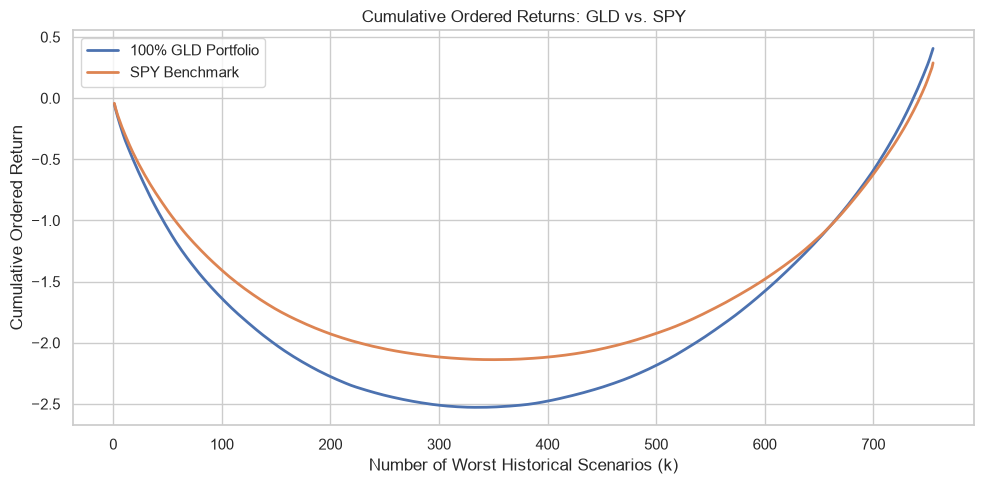

In [85]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    dominance_indices,
    initial_cumulative_returns,
    label="100% GLD Portfolio",
    linewidth=2,
)

ax.plot(
    dominance_indices,
    benchmark_cumulative_returns,
    label="SPY Benchmark",
    linewidth=2,
)

ax.set_title(
    "Cumulative Ordered Returns: GLD vs. SPY"
)

ax.set_xlabel(
    "Number of Worst Historical Scenarios (k)"
)

ax.set_ylabel(
    "Cumulative Ordered Return"
)

ax.legend()

plt.tight_layout()
plt.show()

In [86]:
formation_dates = (
    returns
    .groupby(returns.index.to_period("M"))
    .head(1)
    .index
)

next_formation_date = formation_dates[
    formation_dates > formation_date
][0]

print("Formation date:", formation_date)
print("Next formation date:", next_formation_date)

Formation date: 2017-01-03 00:00:00
Next formation date: 2017-02-01 00:00:00


In [87]:
holding_period_returns = returns.loc[
    (returns.index >= formation_date)
    & (returns.index < next_formation_date)
].copy()

realized_portfolio_returns = (
    holding_period_returns[asset_names]
    @ final_weights
)

realized_portfolio_returns.name = (
    "Exact_SSD_Portfolio"
)

realized_benchmark_returns = (
    holding_period_returns[BENCHMARK_NAME]
)

realized_benchmark_returns.name = (
    "SPY"
)

print(
    "Holding period:",
    holding_period_returns.index.min(),
    "to",
    holding_period_returns.index.max(),
)

print(
    "Number of realized daily returns:",
    len(holding_period_returns),
)

display(
    pd.concat(
        [
            realized_portfolio_returns,
            realized_benchmark_returns,
        ],
        axis=1,
    )
)

Holding period: 2017-01-03 00:00:00 to 2017-01-31 00:00:00
Number of realized daily returns: 20


,Exact_SSD_Portfolio,SPY
Date,,
2017-01-03,0.005192,0.007650
2017-01-04,0.011078,0.005949
2017-01-05,0.004605,-0.000794
2017-01-06,0.002537,0.003578
2017-01-09,-0.004156,-0.003301
2017-01-10,-0.004597,0.000000
2017-01-11,-0.002789,0.002826
2017-01-12,0.002565,-0.002510
2017-01-13,0.000002,0.002295


In [88]:
sorted_realized_portfolio_returns = np.sort(
    realized_portfolio_returns.to_numpy()
)

sorted_realized_benchmark_returns = np.sort(
    realized_benchmark_returns.to_numpy()
)

cumulative_realized_portfolio_returns = (
    np.cumsum(
        sorted_realized_portfolio_returns
    )
)

cumulative_realized_benchmark_returns = (
    np.cumsum(
        sorted_realized_benchmark_returns
    )
)

realized_ssd_slacks = (
    cumulative_realized_portfolio_returns
    - cumulative_realized_benchmark_returns
)

In [89]:
REALIZED_SSD_TOLERANCE = 1e-10

tightest_realized_position = np.argmin(
    realized_ssd_slacks
)

tightest_realized_k = (
    tightest_realized_position + 1
)

minimum_realized_slack = (
    realized_ssd_slacks[
        tightest_realized_position
    ]
)

maximum_realized_violation = max(
    0.0,
    -minimum_realized_slack,
)

realized_ssd_satisfied = (
    minimum_realized_slack
    >= -REALIZED_SSD_TOLERANCE
)

print(
    "One-month realized SSD satisfied:",
    realized_ssd_satisfied,
)

print(
    "Tightest realized k:",
    tightest_realized_k,
)

print(
    "Minimum realized SSD slack:",
    f"{minimum_realized_slack:.10f}",
)

print(
    "Maximum realized violation:",
    f"{maximum_realized_violation:.10f}",
)

print(
    "Realized portfolio daily mean:",
    realized_portfolio_returns.mean(),
)

print(
    "Realized SPY daily mean:",
    realized_benchmark_returns.mean(),
)

One-month realized SSD satisfied: False
Tightest realized k: 6
Minimum realized SSD slack: -0.0087492349
Maximum realized violation: 0.0087492349
Realized portfolio daily mean: 0.0008066394116248508
Realized SPY daily mean: 0.0008954876972120218


In [90]:
dominance_summary = pd.Series(
    {
        "Formation Date":
            formation_date,

        "Next Formation Date":
            next_formation_date,

        "Estimation Scenarios":
            number_of_scenarios,

        "Realized Observations":
            len(realized_portfolio_returns),

        "Estimated SSD Satisfied":
            (
                final_dominance_slacks
                >= -DOMINANCE_TOLERANCE
            ).all(),

        "Estimated Minimum Slack":
            final_dominance_slacks.min(),

        "Realized SSD Satisfied":
            realized_ssd_satisfied,

        "Realized Minimum Slack":
            minimum_realized_slack,

        "Realized Maximum Violation":
            maximum_realized_violation,
    },
    name="Result",
)

dominance_summary.to_frame()

,Result
Formation Date,2017-01-03 00:00:00
Next Formation Date,2017-02-01 00:00:00
Estimation Scenarios,755
Realized Observations,20
Estimated SSD Satisfied,True
Estimated Minimum Slack,0.0
Realized SSD Satisfied,False
Realized Minimum Slack,-0.008749
Realized Maximum Violation,0.008749


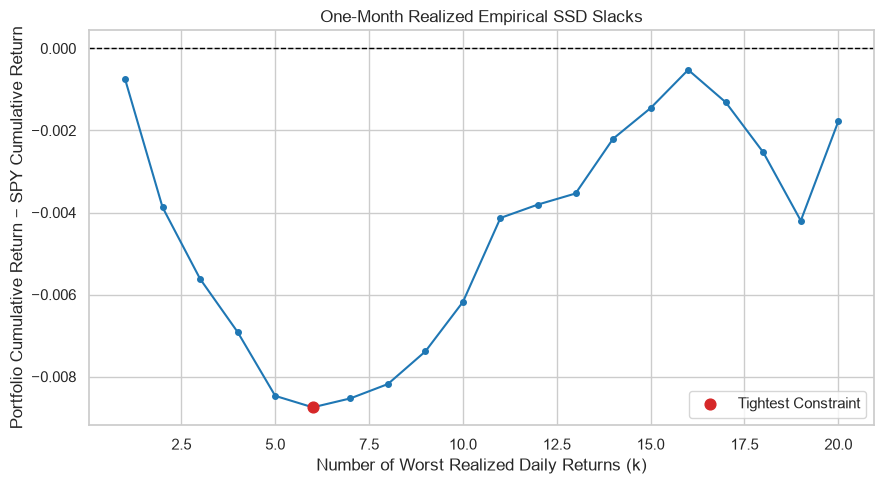

In [91]:
realized_k = np.arange(
    1,
    len(realized_ssd_slacks) + 1,
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    realized_k,
    realized_ssd_slacks,
    marker="o",
    linewidth=1.5,
    markersize=4,
    color="tab:blue",
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.scatter(
    tightest_realized_k,
    minimum_realized_slack,
    color="tab:red",
    s=60,
    zorder=3,
    label="Tightest Constraint",
)

ax.set_title(
    "One-Month Realized Empirical SSD Slacks"
)

ax.set_xlabel(
    "Number of Worst Realized Daily Returns (k)"
)

ax.set_ylabel(
    "Portfolio Cumulative Return − "
    "SPY Cumulative Return"
)

ax.legend()

plt.tight_layout()
plt.show()

In [92]:
def solve_exact_ssd_window(
    estimation_returns,
    asset_names,
    benchmark_name="SPY",
    solver="CLARABEL",
    tolerance=1e-8,
):
    """
    Solve one exact empirical SSD problem using
    a cutting-plane algorithm.
    """

    scenario_matrix = (
        estimation_returns[asset_names]
        .to_numpy(dtype=float)
    )

    benchmark_vector = (
        estimation_returns[benchmark_name]
        .to_numpy(dtype=float)
    )

    benchmark_cumulative = np.cumsum(
        np.sort(benchmark_vector)
    )

    number_of_scenarios = (
        scenario_matrix.shape[0]
    )

    number_of_assets = (
        scenario_matrix.shape[1]
    )

    # Begin with the mean-dominance constraint.
    active_cuts = [
        number_of_scenarios
    ]

    iteration_history = []

    for iteration in range(
        1,
        number_of_scenarios + 1,
    ):
        weight_variable = cp.Variable(
            number_of_assets
        )

        portfolio_scenarios = (
            scenario_matrix
            @ weight_variable
        )

        constraints = [
            cp.sum(weight_variable) == 1,
            weight_variable >= 0,
        ]

        for k in active_cuts:

            if k == number_of_scenarios:
                portfolio_lower_sum = cp.sum(
                    portfolio_scenarios
                )
            else:
                portfolio_lower_sum = (
                    cp.sum_smallest(
                        portfolio_scenarios,
                        k,
                    )
                )

            constraints.append(
                portfolio_lower_sum
                >= benchmark_cumulative[k - 1]
            )

        estimated_mean_return = cp.sum(
            portfolio_scenarios
        ) / number_of_scenarios

        problem = cp.Problem(
            cp.Maximize(
                estimated_mean_return
            ),
            constraints,
        )

        try:
            problem.solve(
                solver=solver
            )
        except cp.error.SolverError:
            return {
                "status": "solver_error",
                "feasible": False,
                "weights": None,
                "number_of_cuts":
                    len(active_cuts),
                "iterations": iteration,
            }

        if problem.status not in [
            "optimal",
            "optimal_inaccurate",
        ]:
            return {
                "status": problem.status,
                "feasible": False,
                "weights": None,
                "number_of_cuts":
                    len(active_cuts),
                "iterations": iteration,
            }

        raw_weights = np.asarray(
            weight_variable.value
        ).reshape(-1)

        realized_historical_portfolio = (
            scenario_matrix @ raw_weights
        )

        portfolio_cumulative = np.cumsum(
            np.sort(
                realized_historical_portfolio
            )
        )

        dominance_slacks = (
            portfolio_cumulative
            - benchmark_cumulative
        )

        tightest_position = np.argmin(
            dominance_slacks
        )

        tightest_k = (
            tightest_position + 1
        )

        minimum_slack = dominance_slacks[
            tightest_position
        ]

        maximum_violation = max(
            0.0,
            -minimum_slack,
        )

        iteration_history.append(
            {
                "Iteration": iteration,
                "Number of Cuts":
                    len(active_cuts),
                "Tightest k":
                    tightest_k,
                "Maximum Violation":
                    maximum_violation,
            }
        )

        if maximum_violation <= tolerance:

            cleaned_weights = np.maximum(
                raw_weights,
                0,
            )

            cleaned_weights /= (
                cleaned_weights.sum()
            )

            weight_series = pd.Series(
                cleaned_weights,
                index=asset_names,
                name="Weight",
            )

            return {
                "status": problem.status,
                "feasible": True,
                "weights": weight_series,
                "number_of_cuts":
                    len(active_cuts),
                "iterations": iteration,
                "estimated_mean_return":
                    realized_historical_portfolio.mean(),
                "benchmark_mean_return":
                    benchmark_vector.mean(),
                "minimum_slack":
                    minimum_slack,
                "tightest_k":
                    tightest_k,
                "iteration_history":
                    iteration_history,
            }

        if tightest_k in active_cuts:
            return {
                "status": "numerical_stall",
                "feasible": False,
                "weights": None,
                "number_of_cuts":
                    len(active_cuts),
                "iterations": iteration,
                "minimum_slack":
                    minimum_slack,
            }

        active_cuts.append(
            tightest_k
        )

        active_cuts.sort()

    return {
        "status": "maximum_iterations",
        "feasible": False,
        "weights": None,
        "number_of_cuts":
            len(active_cuts),
        "iterations":
            number_of_scenarios,
    }

In [93]:
def evaluate_realized_ssd(
    holding_period_returns,
    weights,
    benchmark_name="SPY",
    tolerance=1e-10,
):
    """
    Compare the next-month realized empirical
    distribution with the benchmark.
    """

    portfolio_returns = (
        holding_period_returns[
            weights.index
        ]
        @ weights
    )

    benchmark_returns = (
        holding_period_returns[
            benchmark_name
        ]
    )

    portfolio_cumulative = np.cumsum(
        np.sort(
            portfolio_returns.to_numpy()
        )
    )

    benchmark_cumulative = np.cumsum(
        np.sort(
            benchmark_returns.to_numpy()
        )
    )

    realized_slacks = (
        portfolio_cumulative
        - benchmark_cumulative
    )

    tightest_position = np.argmin(
        realized_slacks
    )

    tightest_k = (
        tightest_position + 1
    )

    minimum_slack = realized_slacks[
        tightest_position
    ]

    maximum_violation = max(
        0.0,
        -minimum_slack,
    )

    return {
        "ssd_satisfied":
            minimum_slack >= -tolerance,

        "minimum_slack":
            minimum_slack,

        "maximum_violation":
            maximum_violation,

        "tightest_k":
            tightest_k,

        "portfolio_mean":
            portfolio_returns.mean(),

        "benchmark_mean":
            benchmark_returns.mean(),

        "portfolio_returns":
            portfolio_returns,

        "benchmark_returns":
            benchmark_returns,

        "slacks":
            realized_slacks,
    }

In [94]:
all_formation_dates = (
    returns
    .groupby(
        returns.index.to_period("M")
    )
    .head(1)
    .index
)

eligible_formation_dates = (
    all_formation_dates[
        all_formation_dates >= backtest_start
    ]
)

# The last formation date has no subsequent
# holding period in the data.
eligible_formation_dates = (
    eligible_formation_dates[:-1]
)

print(
    "First formation date:",
    eligible_formation_dates[0],
)

print(
    "Last formation date:",
    eligible_formation_dates[-1],
)

print(
    "Number of evaluated months:",
    len(eligible_formation_dates),
)

First formation date: 2010-05-03 00:00:00
Last formation date: 2020-03-02 00:00:00
Number of evaluated months: 119


In [95]:
monthly_records = []
monthly_weights = {}
monthly_realized_returns = {}

for month_number, formation_date in enumerate(
    eligible_formation_dates,
    start=1,
):
    next_formation_date = (
        all_formation_dates[
            all_formation_dates
            > formation_date
        ][0]
    )

    estimation_start = (
        formation_date
        - pd.DateOffset(
            years=ESTIMATION_YEARS
        )
    )

    estimation_returns = returns.loc[
        (returns.index >= estimation_start)
        & (returns.index < formation_date)
    ].copy()

    holding_period_returns = returns.loc[
        (returns.index >= formation_date)
        & (returns.index < next_formation_date)
    ].copy()

    optimization_result = (
        solve_exact_ssd_window(
            estimation_returns=
                estimation_returns,

            asset_names=
                asset_names,

            benchmark_name=
                BENCHMARK_NAME,

            solver=
                SOLVER,

            tolerance=
                DOMINANCE_TOLERANCE,
        )
    )

    record = {
        "Formation Date":
            formation_date,

        "Next Formation Date":
            next_formation_date,

        "Estimation Observations":
            len(estimation_returns),

        "Realized Observations":
            len(holding_period_returns),

        "Optimization Status":
            optimization_result["status"],

        "Estimated SSD Feasible":
            optimization_result["feasible"],

        "Number of Cuts":
            optimization_result[
                "number_of_cuts"
            ],

        "Cutting-Plane Iterations":
            optimization_result[
                "iterations"
            ],
    }

    if optimization_result["feasible"]:

        weights_for_month = (
            optimization_result["weights"]
        )

        monthly_weights[
            formation_date
        ] = weights_for_month

        realized_result = (
            evaluate_realized_ssd(
                holding_period_returns=
                    holding_period_returns,

                weights=
                    weights_for_month,

                benchmark_name=
                    BENCHMARK_NAME,
            )
        )

        monthly_realized_returns[
            formation_date
        ] = realized_result[
            "portfolio_returns"
        ]

        record.update(
            {
                "Estimated Minimum Slack":
                    optimization_result[
                        "minimum_slack"
                    ],

                "Estimated Mean Return":
                    optimization_result[
                        "estimated_mean_return"
                    ],

                "Estimated Benchmark Mean":
                    optimization_result[
                        "benchmark_mean_return"
                    ],

                "Realized SSD Satisfied":
                    realized_result[
                        "ssd_satisfied"
                    ],

                "Realized Minimum Slack":
                    realized_result[
                        "minimum_slack"
                    ],

                "Realized Maximum Violation":
                    realized_result[
                        "maximum_violation"
                    ],

                "Realized Tightest k":
                    realized_result[
                        "tightest_k"
                    ],

                "Realized Portfolio Mean":
                    realized_result[
                        "portfolio_mean"
                    ],

                "Realized Benchmark Mean":
                    realized_result[
                        "benchmark_mean"
                    ],
            }
        )

    else:
        record.update(
            {
                "Estimated Minimum Slack":
                    np.nan,

                "Estimated Mean Return":
                    np.nan,

                "Estimated Benchmark Mean":
                    estimation_returns[
                        BENCHMARK_NAME
                    ].mean(),

                "Realized SSD Satisfied":
                    np.nan,

                "Realized Minimum Slack":
                    np.nan,

                "Realized Maximum Violation":
                    np.nan,

                "Realized Tightest k":
                    np.nan,

                "Realized Portfolio Mean":
                    np.nan,

                "Realized Benchmark Mean":
                    holding_period_returns[
                        BENCHMARK_NAME
                    ].mean(),
            }
        )

    monthly_records.append(record)

    if (
        month_number % 12 == 0
        or month_number
        == len(eligible_formation_dates)
    ):
        print(
            f"Completed "
            f"{month_number}/"
            f"{len(eligible_formation_dates)} "
            f"months."
        )

Completed 12/119 months.
Completed 24/119 months.
Completed 36/119 months.
Completed 48/119 months.
Completed 60/119 months.
Completed 72/119 months.
Completed 84/119 months.
Completed 96/119 months.
Completed 108/119 months.
Completed 119/119 months.


In [96]:
monthly_ssd_results = (
    pd.DataFrame(monthly_records)
    .set_index("Formation Date")
)

monthly_ssd_results.head()

,Next Formation Date,Estimation Observations,Realized Observations,Optimization Status,Estimated SSD Feasible,Number of Cuts,Cutting-Plane Iterations,Estimated Minimum Slack,Estimated Mean Return,Estimated Benchmark Mean,Realized SSD Satisfied,Realized Minimum Slack,Realized Maximum Violation,Realized Tightest k,Realized Portfolio Mean,Realized Benchmark Mean
Formation Date,,,,,,,,,,,,,,,,
2010-05-03,2010-06-01,755,20,optimal,True,1,1,0.024143,0.000846,-0.000041,True,0.013825,0.000000,1.0,0.001572,-0.003938
2010-06-01,2010-07-01,755,22,optimal,True,1,1,0.024143,0.000909,-0.000178,True,0.015272,0.000000,1.0,0.001111,-0.002288
2010-07-01,2010-08-02,756,21,optimal,True,1,1,0.024143,0.000965,-0.000226,False,-0.118302,0.118302,21.0,-0.002409,0.003224
2010-08-02,2010-09-01,755,22,optimal,True,1,1,0.024143,0.000865,-0.000103,True,0.023673,0.000000,1.0,0.002536,-0.002031
2010-09-01,2010-10-01,755,21,optimal,True,1,1,0.024143,0.000926,-0.000175,False,-0.039869,0.039869,21.0,0.002240,0.004139


In [107]:
realized_ssd_indicator = (
    monthly_ssd_results[
        "Realized SSD Satisfied"
    ]
    .astype("boolean")
)

number_of_months = len(
    monthly_ssd_results
)

number_estimated_feasible = int(
    monthly_ssd_results[
        "Estimated SSD Feasible"
    ]
    .astype(bool)
    .sum()
)

number_realized_satisfied = int(
    realized_ssd_indicator.sum()
)

number_realized_evaluated = int(
    realized_ssd_indicator.notna().sum()
)

estimated_feasibility_rate = (
    number_estimated_feasible
    / number_of_months
)

realized_success_rate = (
    number_realized_satisfied
    / number_realized_evaluated
)

overall_realized_success_rate = (
    number_realized_satisfied
    / number_of_months
)

print(
    "Total evaluated months:",
    number_of_months,
)

print(
    "Estimated exact SSD feasible months:",
    number_estimated_feasible,
)

print(
    "Estimated feasibility rate:",
    f"{estimated_feasibility_rate:.2%}",
)

print(
    "Months with realized SSD evaluation:",
    number_realized_evaluated,
)

print(
    "Realized SSD satisfied months:",
    number_realized_satisfied,
)

print(
    "Realized success rate "
    "among feasible months:",
    f"{realized_success_rate:.2%}",
)

print(
    "Realized success rate "
    "among all evaluated months:",
    f"{overall_realized_success_rate:.2%}",
)

Total evaluated months: 119
Estimated exact SSD feasible months: 118
Estimated feasibility rate: 99.16%
Months with realized SSD evaluation: 118
Realized SSD satisfied months: 34
Realized success rate among feasible months: 28.81%
Realized success rate among all evaluated months: 28.57%


In [102]:
worst_realized_months = (
    monthly_ssd_results.loc[
        monthly_ssd_results[
            "Realized SSD Satisfied"
        ] == False
    ]
    .sort_values(
        "Realized Maximum Violation",
        ascending=False,
    )
    .head(2)
)

display(
    worst_realized_months[
        [
            "Next Formation Date",
            "Number of Cuts",
            "Realized Tightest k",
            "Realized Minimum Slack",
            "Realized Maximum Violation",
            "Realized Portfolio Mean",
            "Realized Benchmark Mean",
        ]
    ]
)

,Next Formation Date,Number of Cuts,Realized Tightest k,Realized Minimum Slack,Realized Maximum Violation,Realized Portfolio Mean,Realized Benchmark Mean
Formation Date,,,,,,,
2010-07-01,2010-08-02,1,21.0,-0.118302,0.118302,-0.002409,0.003224
2011-01-03,2011-02-01,1,19.0,-0.096219,0.096219,-0.003237,0.001172


In [103]:
best_realized_months = (
    monthly_ssd_results.loc[
        monthly_ssd_results[
            "Realized SSD Satisfied"
        ] == True
    ]
    .sort_values(
        "Realized Minimum Slack",
        ascending=False,
    )
    .head(2)
)

display(
    best_realized_months[
        [
            "Next Formation Date",
            "Number of Cuts",
            "Realized Tightest k",
            "Realized Minimum Slack",
            "Realized Maximum Violation",
            "Realized Portfolio Mean",
            "Realized Benchmark Mean",
        ]
    ]
)

,Next Formation Date,Number of Cuts,Realized Tightest k,Realized Minimum Slack,Realized Maximum Violation,Realized Portfolio Mean,Realized Benchmark Mean
Formation Date,,,,,,,
2020-03-02,2020-04-01,3,1.0,0.033744,0.0,-0.000626,-0.004509
2011-08-01,2011-09-01,1,1.0,0.027635,0.0,0.005248,-0.002051


In [108]:
print(
    monthly_ssd_results[
        "Realized SSD Satisfied"
    ].value_counts()
)

Realized SSD Satisfied
False    84
True     34
Name: count, dtype: int64


In [110]:
selected_example_dates = list(
    worst_realized_months.index
) + list(
    best_realized_months.index
)

for selected_date in selected_example_dates:

    result_type = (
        "Worst Failure"
        if selected_date
        in worst_realized_months.index
        else "Best Success"
    )

    print(
        "\n",
        "=" * 60,
    )

    print(
        result_type,
        "| Formation date:",
        selected_date.date(),
    )

    print(
        "Holding period ends:",
        monthly_ssd_results.loc[
            selected_date,
            "Next Formation Date",
        ].date(),
    )

    display(
        monthly_weights[
            selected_date
        ]
        .sort_values(ascending=False)
        .to_frame()
        .style.format("{:.2%}")
    )


Worst Failure | Formation date: 2010-07-01
Holding period ends: 2010-08-02


,Weight
GLD,100.00%
TLT,0.00%
IEF,0.00%
EEM,0.00%
VNQ,0.00%
LQD,0.00%
HYG,0.00%
QQQ,0.00%
DBC,0.00%
IWM,0.00%



Worst Failure | Formation date: 2011-01-03
Holding period ends: 2011-02-01


,Weight
GLD,100.00%
VNQ,0.00%
DBC,0.00%
EFA,0.00%
EEM,0.00%
TLT,0.00%
IEF,0.00%
LQD,0.00%
QQQ,0.00%
HYG,0.00%



Best Success | Formation date: 2020-03-02
Holding period ends: 2020-04-01


,Weight
QQQ,76.10%
TLT,23.90%
GLD,0.00%
LQD,0.00%
IEF,0.00%
VNQ,0.00%
HYG,0.00%
EFA,0.00%
EEM,0.00%
IWM,0.00%



Best Success | Formation date: 2011-08-01
Holding period ends: 2011-09-01


,Weight
GLD,100.00%
VNQ,0.00%
EEM,0.00%
QQQ,0.00%
IWM,0.00%
HYG,0.00%
LQD,0.00%
TLT,0.00%
IEF,0.00%
EFA,0.00%


## Rolling Out-of-Sample Results

The exact empirical SSD model was evaluated at 119 monthly formation dates. At each formation date, the preceding three years of daily returns were used to construct the empirical return distributions. The optimizer then maximized estimated mean return subject to long-only, fully invested, and exact SSD constraints relative to SPY. The optimized weights were applied to the daily returns observed during the following month.

An exact in-sample SSD solution was found in 118 of the 119 evaluated months, corresponding to a feasibility rate of 99.16%. Among these 118 portfolios, 34 continued to empirically SSD-dominate SPY during the subsequent one-month holding period. The resulting realized SSD success rate was 28.81% among months with an estimated feasible solution and 28.57% among all evaluated months.

Although out-of-sample dominance occurred substantially more often than a single isolated case, it remained far from persistent. Exact historical SSD feasibility therefore did not provide a reliable guarantee of realized dominance during the following month. This gap reflects the difference between dominance under the estimated historical distribution and dominance under the unknown future distribution.

The optimized portfolios were frequently highly concentrated. Some of the most severe realized failures allocated approximately 100% to GLD. Several successful months were also concentrated, including portfolios dominated by GLD or by a combination of QQQ and TLT. This shows that stochastic dominance does not itself imply diversification. A concentrated portfolio may satisfy SSD during a particular sample, but its performance remains sensitive to changes in the return distribution of a small number of assets.

The results suggest that the model frequently selected assets that had performed particularly well over the historical estimation period. Because the objective maximized historical mean return and imposed no direct concentration penalty, historical winners could receive nearly the entire portfolio allocation. These historical distributional advantages persisted into the following month in approximately 29% of the evaluated cases, but disappeared in the majority of months.

The three-year estimation window may contain observations from market regimes that are no longer representative of the following month. A shorter one-year window could respond more quickly to changing market conditions and will be considered as a sensitivity test. However, it would also reduce the number of historical scenarios from approximately 756 to 252, increasing sampling error and potentially making the optimized weights less stable.

The next analysis replaces the exact binary dominance requirement with a relaxed stochastic-dominance formulation. Controlled violations will be permitted and penalized in the objective, allowing dominance violations to be measured by magnitude rather than classified only as success or failure. Concentration controls and alternative estimation-window lengths can then be examined as additional robustness choices.
